In [1]:
from pathlib import Path

import pandas as pd

from dd_kable_analysis.config_loader import load_config


In [5]:
import re

from dd_kable_analysis.data_io import load_tsv_data, resolve_file

cfg = load_config()

subject_list_path = Path(cfg.subject_lists) / 'mvpa_subject_list.txt'
subject_ids = [
    line.strip() for line in subject_list_path.read_text().splitlines() if line.strip()
]

run_re = re.compile(r'_run-([^_]+)_')

all_runs = []
missing_bids = []
missing_sv = []

for sub_id in subject_ids:
    sv_dir = Path(cfg.output_root) / 'subjective_value_estimates' / f'sub-{sub_id}'

    # Get all SV paths for this subject
    sv_paths = sorted(
        sv_dir.glob(
            f'ses-*/func/sub-{sub_id}_ses-*_task-dd_run-*_desc-subjectivevalue_events.tsv'
        )
    )

    sv_by_run = {}
    for p in sv_paths:
        m = run_re.search(p.name)
        if m:
            sv_by_run[m.group(1)] = p

    if not sv_paths:
        missing_sv.append(sub_id)

    # Try each run using resolve_file for BIDS data
    # We need to figure out which runs exist for this subject
    # Try runs 1-5 and catch failures
    for run_num in range(1, 6):
        run_id = str(run_num)

        try:
            bids_path = resolve_file(cfg, sub_id, 'scan1', run_id, 'behav')
        except ValueError:
            # This run doesn't exist for this subject, skip it
            continue

        bids_df = load_tsv_data(bids_path).copy()
        bids_df['sub_id'] = sub_id
        bids_df['run'] = run_id
        bids_df['source_bids_tsv'] = str(bids_path)
        bids_df['_onset_key'] = pd.to_numeric(bids_df['onset'], errors='coerce').round(
            6
        )

        sv_path = sv_by_run.get(run_id)

        if sv_path is not None:
            sv_df = load_tsv_data(sv_path).copy()
            sv_df['_onset_key'] = pd.to_numeric(sv_df['onset'], errors='coerce').round(
                6
            )

            # Keep subjective-value columns if present
            sv_cols = ['_onset_key', 'SV_LL', 'SV_chosen', 'SV_unchosen', 'SV_SS', 'DV']
            sv_cols = [c for c in sv_cols if c in sv_df.columns]
            sv_df = sv_df[sv_cols].drop_duplicates(subset=['_onset_key'], keep='first')

            merged = bids_df.merge(
                sv_df, on='_onset_key', how='left', validate='many_to_one'
            )
            merged['source_sv_tsv'] = str(sv_path)
        else:
            merged = bids_df.copy()
            merged['source_sv_tsv'] = pd.NA

        merged = merged.drop(columns=['_onset_key'])
        all_runs.append(merged)

if all_runs:
    mvpa_merged_df = pd.concat(all_runs, ignore_index=True)
else:
    print('Warning: No data loaded!')
    mvpa_merged_df = pd.DataFrame()

# Backward-compatible alias for quick inspection in later cells
mvpa_behav_df = mvpa_merged_df

print(f'Subjects in MVPA list: {len(subject_ids)}')
print(f'Subjects missing subjective-value TSVs: {len(missing_sv)}')
print(f'Merged rows: {len(mvpa_merged_df)}')
print(f'Columns: {list(mvpa_merged_df.columns)}')

mvpa_merged_df.head()


Subjects in MVPA list: 123
Subjects missing subjective-value TSVs: 0
Merged rows: 14730
Columns: ['onset', 'duration', 'amount', 'Delay', 'choseAccept', 'RT', 'choseRight', 'sub_id', 'run', 'source_bids_tsv', 'source_sv_tsv']


/tmp/ipykernel_30837/2852585028.py:82: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  mvpa_merged_df = pd.concat(all_runs, ignore_index=True)


,onset,duration,amount,Delay,choseAccept,RT,choseRight,sub_id,run,source_bids_tsv,source_sv_tsv
0,15.822,4,66,58,1.0,1.993,1.0,dmp0011,1,/oak/stanford/groups/russpold/users/buckholtz/...,NaN
1,24.855,4,39,95,0.0,1.024,0.0,dmp0011,1,/oak/stanford/groups/russpold/users/buckholtz/...,NaN
2,32.888,4,69,172,0.0,1.071,0.0,dmp0011,1,/oak/stanford/groups/russpold/users/buckholtz/...,NaN
3,42.937,4,23,42,0.0,1.101,0.0,dmp0011,1,/oak/stanford/groups/russpold/users/buckholtz/...,NaN
4,56.987,4,77,142,1.0,1.739,1.0,dmp0011,1,/oak/stanford/groups/russpold/users/buckholtz/...,NaN


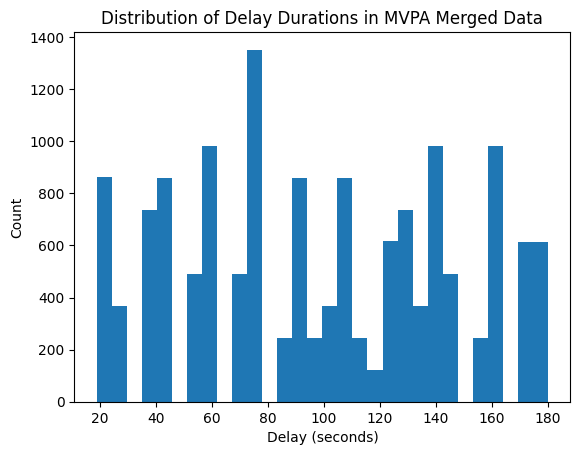

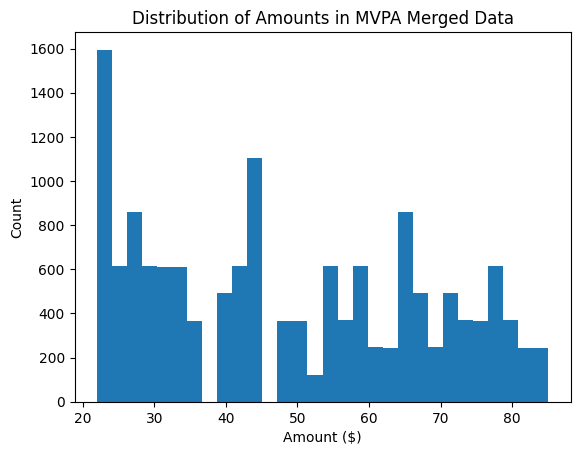

In [8]:
import matplotlib.pyplot as plt

plt.hist(mvpa_merged_df['Delay'].dropna(), bins=30)
plt.xlabel('Delay (seconds)')
plt.ylabel('Count')
plt.title('Distribution of Delay Durations in MVPA Merged Data')
plt.show()

plt.hist(mvpa_merged_df['amount'].dropna(), bins=30)
plt.xlabel('Amount ($)')
plt.ylabel('Count')
plt.title('Distribution of Amounts in MVPA Merged Data')
plt.show()

In [11]:
mvpa_merged_df['amount'].min()

22

/tmp/ipykernel_30837/2069903088.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mvpa_merged_df.groupby(['sub_id', 'delay_bin', 'amount_bin'])
/tmp/ipykernel_30837/2069903088.py:30: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  mean_counts = bin_counts.pivot_table(
/tmp/ipykernel_30837/2069903088.py:33: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  std_counts = bin_counts.pivot_table(


Bin counts shape: (3075, 4)

First few rows:
    sub_id delay_bin amount_bin  count
0  dmp0011        Q1         Q1      4
1  dmp0011        Q1         Q2      5
2  dmp0011        Q1         Q3      6
3  dmp0011        Q1         Q4      5
4  dmp0011        Q1         Q5      5
5  dmp0011        Q2         Q1      5
6  dmp0011        Q2         Q2      7
7  dmp0011        Q2         Q3      2
8  dmp0011        Q2         Q4      6
9  dmp0011        Q2         Q5      4


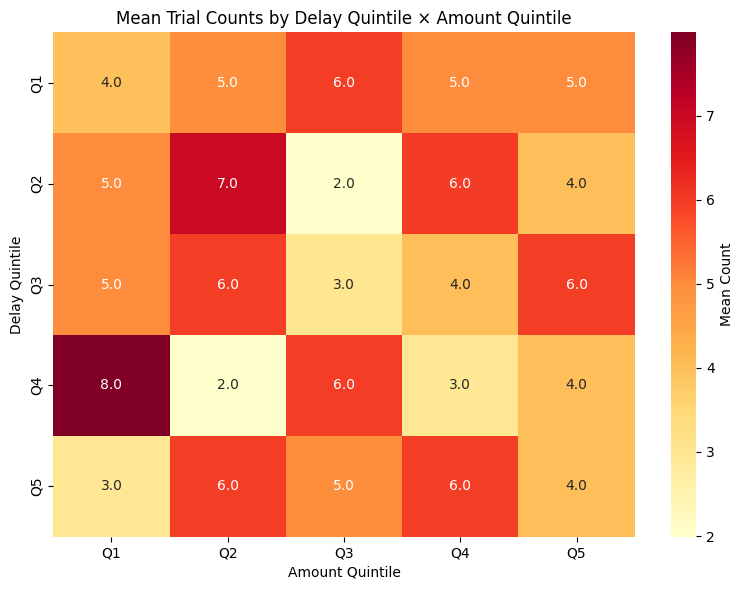

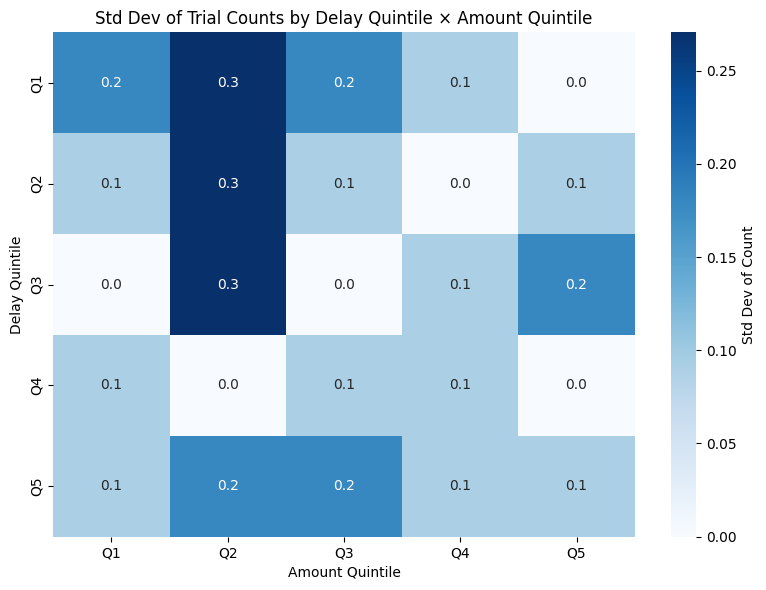

In [20]:
import seaborn as sns

# Create quintile bins for delay and amount
mvpa_merged_df['delay_bin'] = pd.qcut(
    mvpa_merged_df['Delay'],
    q=5,
    labels=[f'Q{i + 1}' for i in range(5)],
    duplicates='drop',
)

mvpa_merged_df['amount_bin'] = pd.qcut(
    mvpa_merged_df['amount'],
    q=5,
    labels=[f'Q{i + 1}' for i in range(5)],
    duplicates='drop',
)

# Get counts for each subject in each bin combination
bin_counts = (
    mvpa_merged_df.groupby(['sub_id', 'delay_bin', 'amount_bin'])
    .size()
    .reset_index(name='count')
)

print(f'Bin counts shape: {bin_counts.shape}')
print('\nFirst few rows:')
print(bin_counts.head(10))

# Create pivot tables for matrix plots
mean_counts = bin_counts.pivot_table(
    index='delay_bin', columns='amount_bin', values='count', aggfunc='mean'
)
std_counts = bin_counts.pivot_table(
    index='delay_bin', columns='amount_bin', values='count', aggfunc='std'
)

# Plot mean counts
plt.figure(figsize=(8, 6))
sns.heatmap(
    mean_counts, annot=True, fmt='.1f', cmap='YlOrRd', cbar_kws={'label': 'Mean Count'}
)
plt.title('Mean Trial Counts by Delay Quintile × Amount Quintile')
plt.xlabel('Amount Quintile')
plt.ylabel('Delay Quintile')
plt.tight_layout()
plt.show()

# Plot std of counts
plt.figure(figsize=(8, 6))
sns.heatmap(
    std_counts,
    annot=True,
    fmt='.1f',
    cmap='Blues',
    cbar_kws={'label': 'Std Dev of Count'},
)
plt.title('Std Dev of Trial Counts by Delay Quintile × Amount Quintile')
plt.xlabel('Amount Quintile')
plt.ylabel('Delay Quintile')
plt.tight_layout()
plt.show()


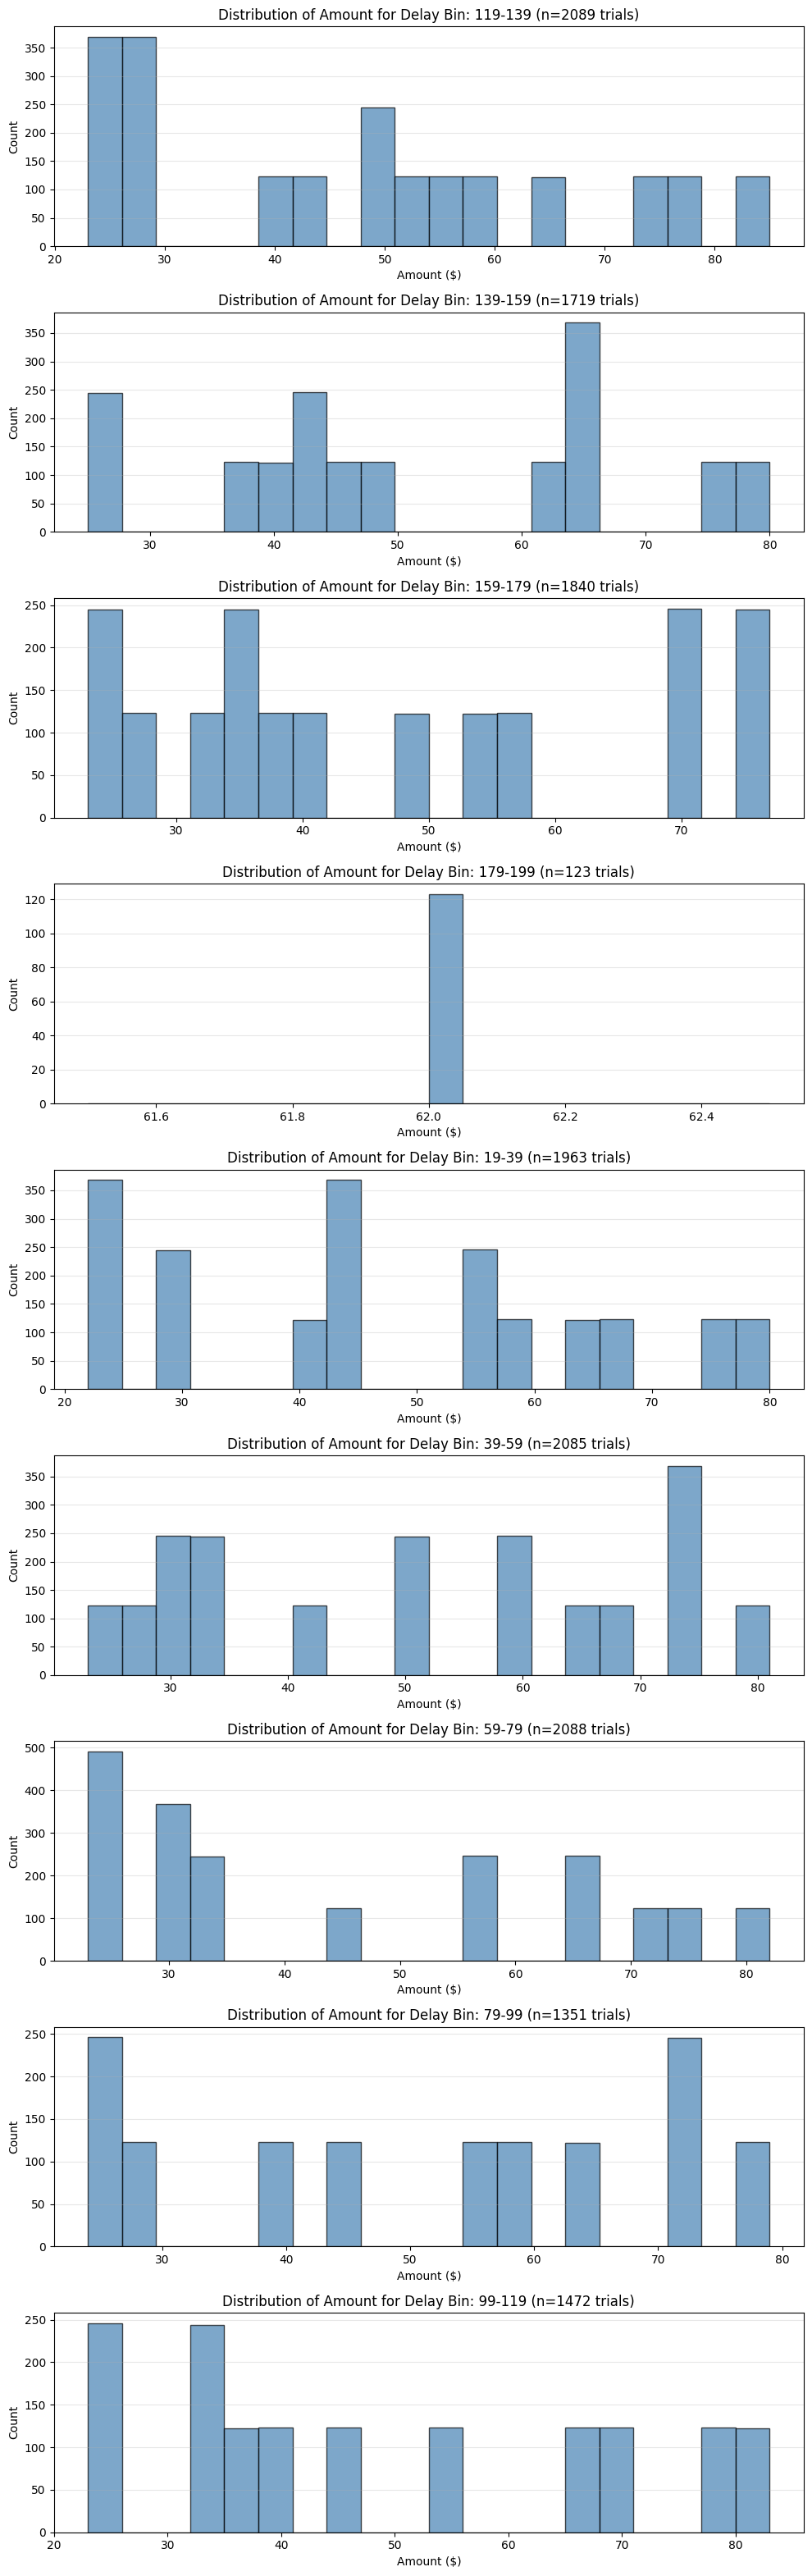

In [18]:
# Plot histogram of amount for each delay bin level
delay_bins_unique = sorted(mvpa_merged_df['delay_bin'].dropna().unique())
n_delay_bins = len(delay_bins_unique)

# Create subplots
fig, axes = plt.subplots(n_delay_bins, 1, figsize=(10, 3.5 * n_delay_bins))
if n_delay_bins == 1:
    axes = [axes]

for idx, delay_bin in enumerate(delay_bins_unique):
    data_in_bin = mvpa_merged_df[mvpa_merged_df['delay_bin'] == delay_bin][
        'amount'
    ].dropna()

    axes[idx].hist(
        data_in_bin, bins=20, edgecolor='black', alpha=0.7, color='steelblue'
    )
    axes[idx].set_xlabel('Amount ($)')
    axes[idx].set_ylabel('Count')
    axes[idx].set_title(
        f'Distribution of Amount for Delay Bin: {delay_bin} (n={len(data_in_bin)} trials)'
    )
    axes[idx].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


In [ ]:
# 5 levels of delay (quintiles) and 3 levels of amount (tertiles)
mvpa_merged_df['delay_5lvl'] = pd.qcut(
    mvpa_merged_df['Delay'],
    q=5,
    labels=[f'D{i + 1}' for i in range(5)],
    duplicates='drop',
)

mvpa_merged_df['amount_3lvl'] = pd.qcut(
    mvpa_merged_df['amount'],
    q=3,
    labels=[f'A{i + 1}' for i in range(3)],
    duplicates='drop',
)

# Counts per subject for each delay x amount bin
bin_counts_5x3 = (
    mvpa_merged_df.groupby(['sub_id', 'delay_5lvl', 'amount_3lvl'])
    .size()
    .reset_index(name='count')
)

print(f'bin_counts_5x3 shape: {bin_counts_5x3.shape}')
print(bin_counts_5x3.head(12))

# Mean and std matrices across subjects
mean_counts_5x3 = bin_counts_5x3.pivot_table(
    index='delay_5lvl', columns='amount_3lvl', values='count', aggfunc='mean'
)
std_counts_5x3 = bin_counts_5x3.pivot_table(
    index='delay_5lvl', columns='amount_3lvl', values='count', aggfunc='std'
)

display(mean_counts_5x3)
display(std_counts_5x3)
